# **Liver Disease Prediction**
## Weekly Class AI/ML Advanced - Final Project
---

<br>

### 😎 **Group 2** 😎
1. EDA: Rasya
2. Data Cleaning: Sandy Setiawan
3. Feature Engineering: Sandy Setiawan
4. Model Selection: fadia
5. Hyperparameter Tuning: fadia
6. Model Evaluation:Danu
7. Model Serialization: Salwa
8. App Development: Arif
9. Model Integration: Salwa
10. Cloud Deployment: Salwa

<br>

### 🧐 **Case** 🧐
Penyakit liver (hati) merupakan salah satu kondisi medis yang sering dijuluki "silent killer" karena gejalanya jarang muncul hingga kerusakan hati sudah mencapai tahap yang parah (seperti sirosis atau gagal hati). Saat ini, diagnosis sangat bergantung pada analisis tes darah pasien, atau yang dikenal dengan Liver Function Test (LFT).

Di rumah sakit dengan volume pasien yang tinggi, dokter umum atau tenaga medis di fasilitas kesehatan tingkat pertama sering kali kewalahan menganalisis puluhan hingga ratusan hasil tes darah setiap harinya. Keterlambatan atau kesalahan dalam membaca pola tes darah ini bisa berakibat fatal bagi pasien.

Sebagai seorang Machine Learning Engineer, Anda diminta untuk membangun sebuah aplikasi Diagnostic Decision Support System (Sistem Pendukung Keputusan Diagnostik) berbasis antarmuka web. Aplikasi ini harus mampu memprediksi secara instan apakah seorang pasien mengidap penyakit liver atau tidak, berdasarkan input parameter dari hasil tes darah mereka. Aplikasi yang Anda-deploy nantinya akan digunakan oleh staf medis atau laboratorium sebagai "opini kedua" (second opinion) atau alat skrining awal untuk memprioritaskan pasien mana yang membutuhkan rujukan ke dokter spesialis atau pemeriksaan ultrasonografi (USG) lebih lanjut.

<br>

### 📚 **Dataset** 📚
[Liver Patient Dataset](https://www.kaggle.com/datasets/shauryasrivastava01/liver-patient-dataset)

Owner of the Dataset (@ Kaggle):
* *Shaurya Srivastava*

<br>

### 💬 **Dataset's Description** 💬
Liver cirrhosis and related liver diseases are increasing globally due to rising alcohol consumption, chronic hepatitis infections, and obesity. Early detection is crucial for improving patient outcomes, yet diagnosis effectiveness may vary across different sub-populations, especially across genders.

This dataset contains medical records of patients from the North-East region of Andhra Pradesh, India. It is widely used for building machine learning models to predict liver disease.

<br>

### 📍 **Dataset's Features** 📍
* `Age`: Age of the person
* `Gender`: Gender of the person
* `TB`: Total Bilirubin
* `DB`: Direct Bilirubin
* `Alkphos`: Alkaline Phosphotase
* `Sgpt`: Alamine Aminotransferase
* `Sgot`: Aspartate Aminotransferase
* `TP`: Total Proteins
* `ALB`: Albumin
* `A/G Ratio`: Albumin and Globulin Ratio
* `Selector`: Target

<br>

### 📝 **NOTE** 📝
- Notebook ini merupakan tempat kalian melatih model yang akan kalian deploy melalui streamlit, notebook ini mencakup EDA hingga Model Serialization
- Kalian boleh mengikuti template pengerjaan kode di bawah yang sudah disiapkan oleh core team. Jika kalian memiliki preferensi pengerjaan kode sendiri, feel free untuk diubah yaaa
- Semangat 💪🔥

# Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import joblib

In [2]:
# Load dataset into Pandas DataFrame
df = pd.read_csv('../data/raw/liver_patient_dataset.csv')

# Display dataset's first five rows
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


# 📊 Preprocessing

## EDA

In [3]:
print(f'Jumlah baris  : {df.shape[0]}')
print(f'Jumlah kolom  : {df.shape[1]}')
print(f'\nNama kolom    : {df.columns.tolist()}')

Jumlah baris  : 583
Jumlah kolom  : 11

Nama kolom    : ['Age', 'Gender', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio', 'Selector']


In [4]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

           Missing Count  Missing (%)
Age                    0          0.0
Gender                 0          0.0
TB                     0          0.0
DB                     0          0.0
Alkphos                0          0.0
Sgpt                   0          0.0
Sgot                   0          0.0
TP                     0          0.0
ALB                    0          0.0
A/G Ratio              0          0.0
Selector               0          0.0

Total missing values: 0


In [5]:
print(f'Jumlah data duplikat: {df.duplicated().sum()}')

Jumlah data duplikat: 13


Interpretasi :

Dataset tidak memiliki missing values. Terdapat **13 baris duplikat**

###Univariate Analysis

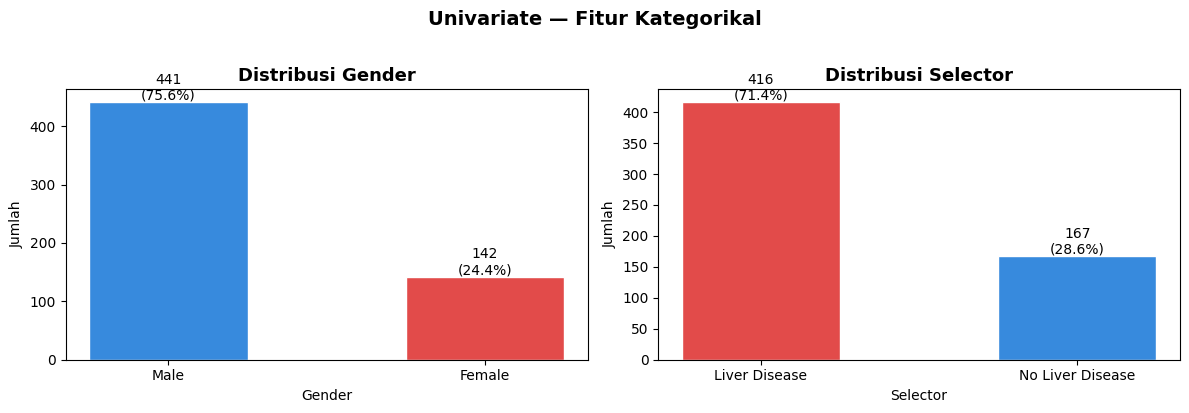

In [6]:
cat_cols = ['Gender', 'Selector']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    pct    = df[col].value_counts(normalize=True) * 100
    colors = ['#E24B4A', '#378ADD'] if col == 'Selector' else ['#378ADD', '#E24B4A']
    bars = axes[i].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(f'Distribusi {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    for bar, (label, val) in zip(bars, counts.items()):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 4,
                     f'{val}\n({pct[label]:.1f}%)',
                     ha='center', fontsize=10)

plt.suptitle('Univariate — Fitur Kategorikal', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for col in cat_cols:
    freq = pd.DataFrame({
        'Count'  : df[col].value_counts(),
        'Percent': (df[col].value_counts(normalize=True) * 100).round(2)
    })

Interpretasi:

- **Gender:** Dataset didominasi oleh pasien **laki-laki (75.6%)** dibanding perempuan (24.4%), menunjukkan distribusi gender yang tidak seimbang.


---


- **Selector (Target):** Terdapat **class imbalance** — sebanyak 71.4% pasien didiagnosis Liver Disease dan hanya 28.6% No Liver Disease. Rasio ~2.5:1 ini perlu ditangani saat modeling menggunakan `class_weight='balanced'` atau teknik oversampling seperti SMOTE.

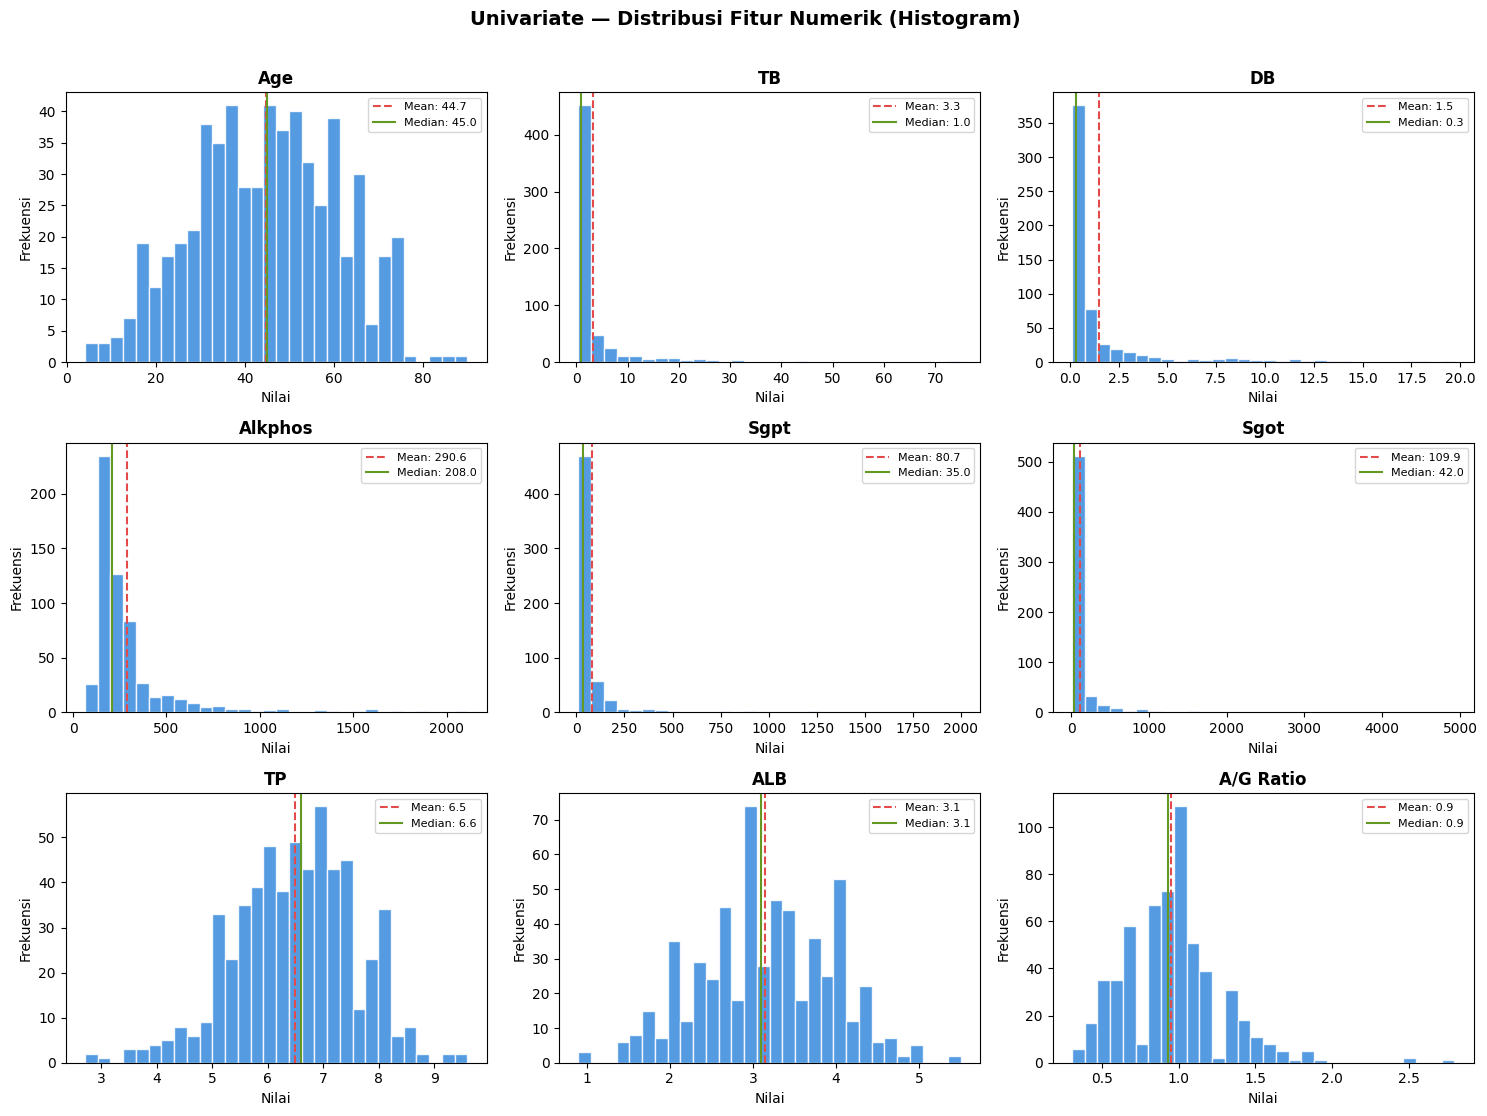

In [7]:
num_cols = ['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='#378ADD', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(),   color='#E24B4A', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='#639922', linestyle='-',  linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

plt.suptitle('Univariate — Distribusi Fitur Numerik (Histogram)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

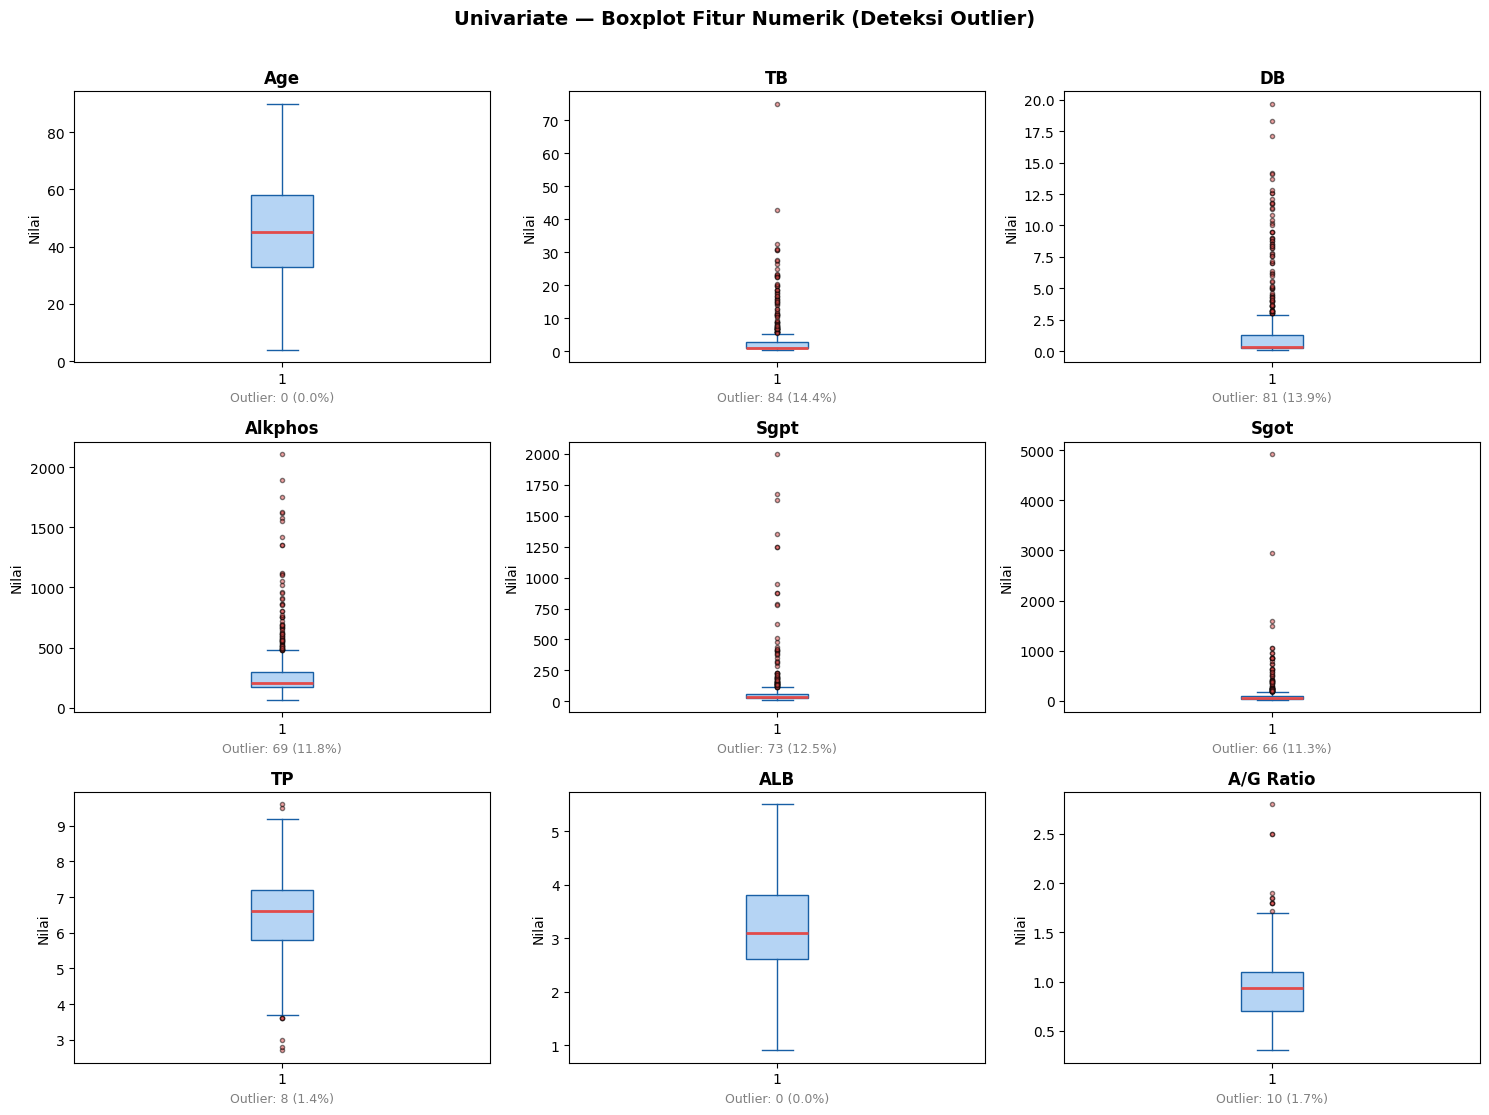

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
                    medianprops=dict(color='#E24B4A', linewidth=2),
                    whiskerprops=dict(color='#185FA5'),
                    capprops=dict(color='#185FA5'),
                    flierprops=dict(marker='o', markerfacecolor='#E24B4A', markersize=3, alpha=0.5))
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Nilai')

    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = int(((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum())
    axes[i].set_xlabel(f'Outlier: {n_out} ({n_out/len(df)*100:.1f}%)', fontsize=9, color='gray')

plt.suptitle('Univariate — Boxplot Fitur Numerik (Deteksi Outlier)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

 Interpretasi :


- **Age:** Distribusi mendekati normal dengan rentang 4–90 tahun.


---



- **TB, DB, Sgpt, Sgot, Alkphos:** Distribusi sangat **right-skewed**  dengan nilai skewness tinggi. Hal ini disebabkan adanya outlier ekstrem pada pasien dengan kondisi liver parah

---


- **TP, ALB, A/G Ratio:** Distribusi lebih simetris dan mendekati normal, dengan jumlah outlier yang sedikit.

---


- **Outlier terbanyak:** TB (14.4%), DB (13.9%), Sgpt (12.5%) — tangani dengan **median imputation**, bukan di-drop.

###Bivariate Anylisis

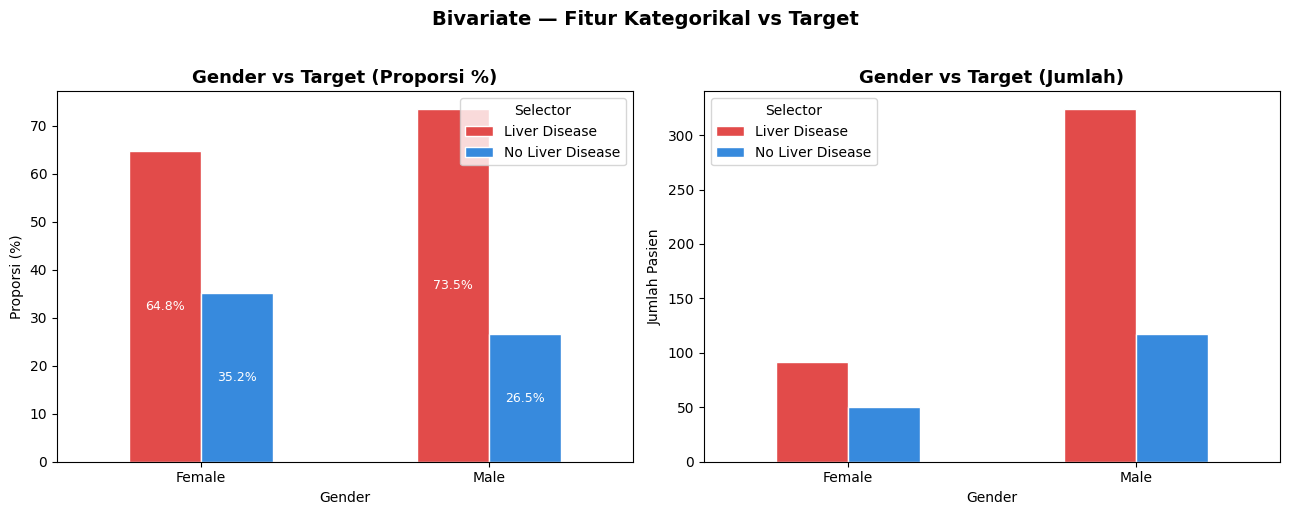

Chi-Square Test — Gender vs Selector:
  Chi2 = 3.5466, p-value = 0.0597, df = 1
  Kesimpulan: Tidak ada hubungan signifikan (α = 0.05)


In [9]:
from scipy.stats import chi2_contingency

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct = pd.crosstab(df['Gender'], df['Selector'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', ax=axes[0], color=['#E24B4A', '#378ADD'],
            edgecolor='white', width=0.5)
axes[0].set_title('Gender vs Target (Proporsi %)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Proporsi (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Selector')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9, color='white')

ct.plot(kind='bar', ax=axes[1], color=['#E24B4A', '#378ADD'],
        edgecolor='white', width=0.5)
axes[1].set_title('Gender vs Target (Jumlah)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Jumlah Pasien')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Selector')

plt.suptitle('Bivariate — Fitur Kategorikal vs Target', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

chi2, p, dof, _ = chi2_contingency(ct)
print(f'Chi-Square Test — Gender vs Selector:')
print(f'  Chi2 = {chi2:.4f}, p-value = {p:.4f}, df = {dof}')
print(f'  Kesimpulan: {"Terdapat hubungan signifikan" if p < 0.05 else "Tidak ada hubungan signifikan"} (α = 0.05)')

  Interpretasi :
  
- Proporsi Liver Disease pada **laki-laki (73.5%)** lebih tinggi dibanding **perempuan (64.8%)**.


---


- Uji **Chi-Square** menunjukkan apakah perbedaan ini signifikan secara statistik. Jika p-value < 0.05, berarti gender memiliki hubungan yang bermakna dengan diagnosis liver disease.

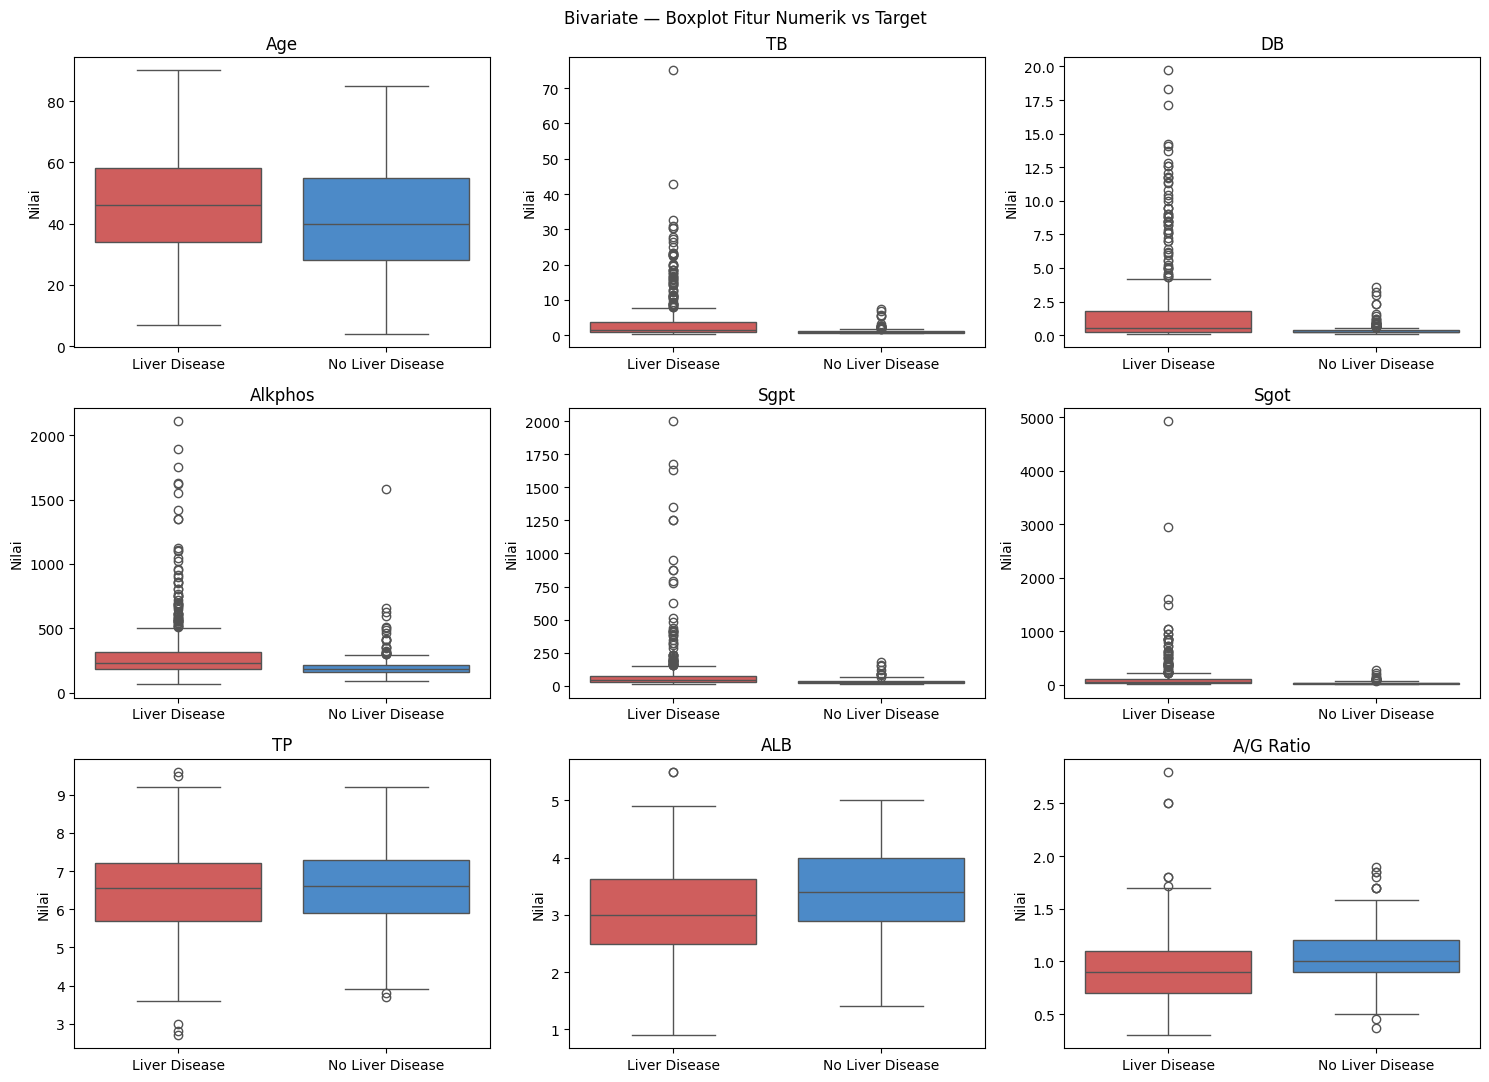

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        x='Selector',
        y=col,
        hue='Selector',
        palette=['#E24B4A', '#378ADD'],
        ax=axes[i],
        legend=False
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Nilai')

plt.suptitle('Bivariate — Boxplot Fitur Numerik vs Target')
plt.tight_layout()
plt.show()

In [11]:
from scipy.stats import mannwhitneyu

ld  = df[df['Selector'] == 'Liver Disease']
nld = df[df['Selector'] == 'No Liver Disease']

print(f'{"Fitur":<12} {"Mean LD":>10} {"Mean NLD":>10} {"Selisih %":>10} {"p-value":>10} {"Signifikan":>12}')
print('-' * 65)
for col in num_cols:
    mean_ld  = ld[col].mean()
    mean_nld = nld[col].mean()
    diff_pct = (mean_ld - mean_nld) / mean_nld * 100
    stat, p  = mannwhitneyu(ld[col], nld[col], alternative='two-sided')
    sig      = '✅ Ya' if p < 0.05 else '❌ Tidak'
    print(f'{col:<12} {mean_ld:>10.2f} {mean_nld:>10.2f} {diff_pct:>+10.1f}% {p:>10.4f} {sig:>12}')

Fitur           Mean LD   Mean NLD  Selisih %    p-value   Signifikan
-----------------------------------------------------------------
Age               46.15      41.24      +11.9%     0.0018         ✅ Ya
TB                 4.16       1.14     +264.5%     0.0000         ✅ Ya
DB                 1.92       0.40     +385.2%     0.0000         ✅ Ya
Alkphos          319.01     219.75      +45.2%     0.0000         ✅ Ya
Sgpt              99.61      33.65     +196.0%     0.0000         ✅ Ya
Sgot             137.70      40.69     +238.4%     0.0000         ✅ Ya
TP                 6.46       6.54       -1.3%     0.4371      ❌ Tidak
ALB                3.06       3.34       -8.5%     0.0001         ✅ Ya
A/G Ratio          0.91       1.03      -11.1%     0.0000         ✅ Ya


Presentasi :

- **TB (+265%), DB (+380%), Sgpt (+196%), Sgot (+238%), Alkphos (+45%)** jauh lebih tinggi pada pasien Liver Disease — ini merupakan **fitur paling diskriminatif** dan kemungkinan besar akan menjadi fitur terpenting di model.

---


- **ALB (−8%) dan A/G Ratio (−12%)** lebih rendah pada Liver Disease, mengindikasikan fungsi sintesis protein hati yang menurun.

---


- **TP** hampir tidak berbeda antar kelas (selisih <2%) — kontribusinya terhadap prediksi kemungkinan rendah.

---


- Uji **Mann-Whitney U** digunakan karena distribusi fitur tidak normal. Fitur dengan p-value < 0.05 memiliki perbedaan yang **signifikan secara statistik** antara dua kelas.

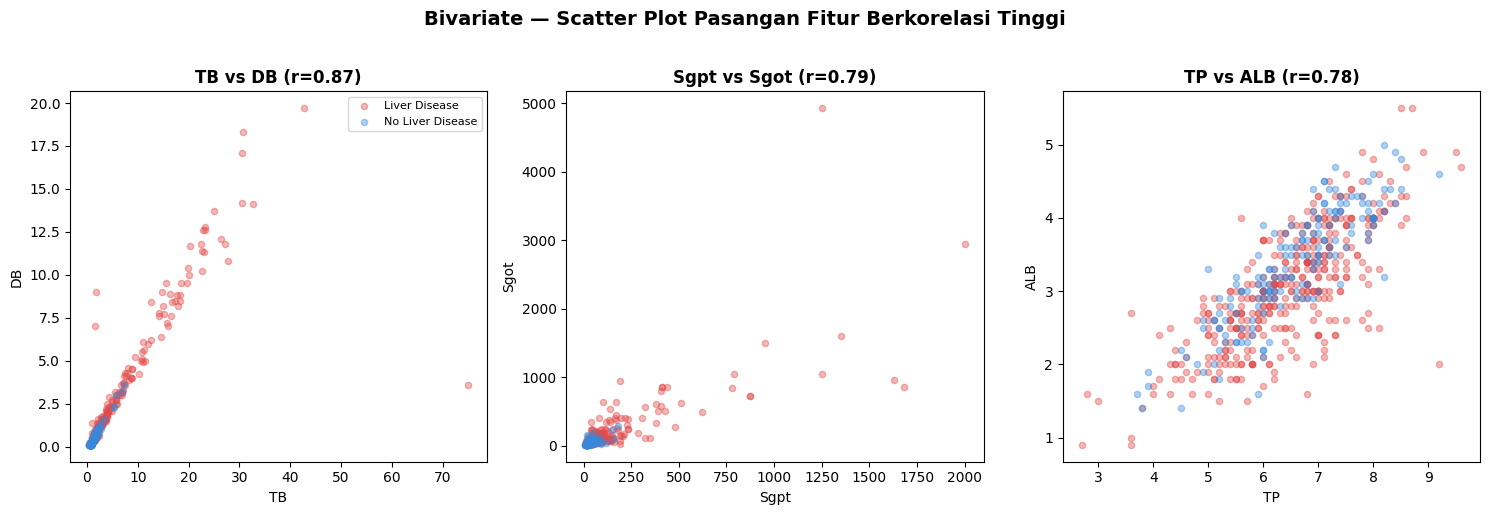

In [12]:
high_corr_pairs = [
    ('TB',   'DB',        'TB vs DB (r=0.87)'),
    ('Sgpt', 'Sgot',      'Sgpt vs Sgot (r=0.79)'),
    ('TP',   'ALB',       'TP vs ALB (r=0.78)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette   = {'Liver Disease': '#E24B4A', 'No Liver Disease': '#378ADD'}

for ax, (x, y, title) in zip(axes, high_corr_pairs):
    for cls, color in palette.items():
        subset = df[df['Selector'] == cls]
        ax.scatter(subset[x], subset[y], c=color, alpha=0.4, s=20, label=cls)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(x)
    ax.set_ylabel(y)

axes[0].legend(fontsize=8, loc='upper right')
plt.suptitle('Bivariate — Scatter Plot Pasangan Fitur Berkorelasi Tinggi',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Interpretasi:

- **TB–DB** dan **Sgpt–Sgot** menunjukkan pola sebaran yang jelas memisahkan dua kelas — pasien Liver Disease (merah) cenderung memiliki nilai lebih tinggi di kedua fitur sekaligus.


---


- **TP–ALB** memiliki sebaran yang lebih tumpang tindih antar kelas, mengonfirmasi bahwa pasangan ini kurang diskriminatif.


---


- Korelasi tinggi antar pasangan ini mengindikasikan **multikolinearitas** — perlu dipertimbangkan saat menggunakan model linear.


---



###Multivariate Analysis

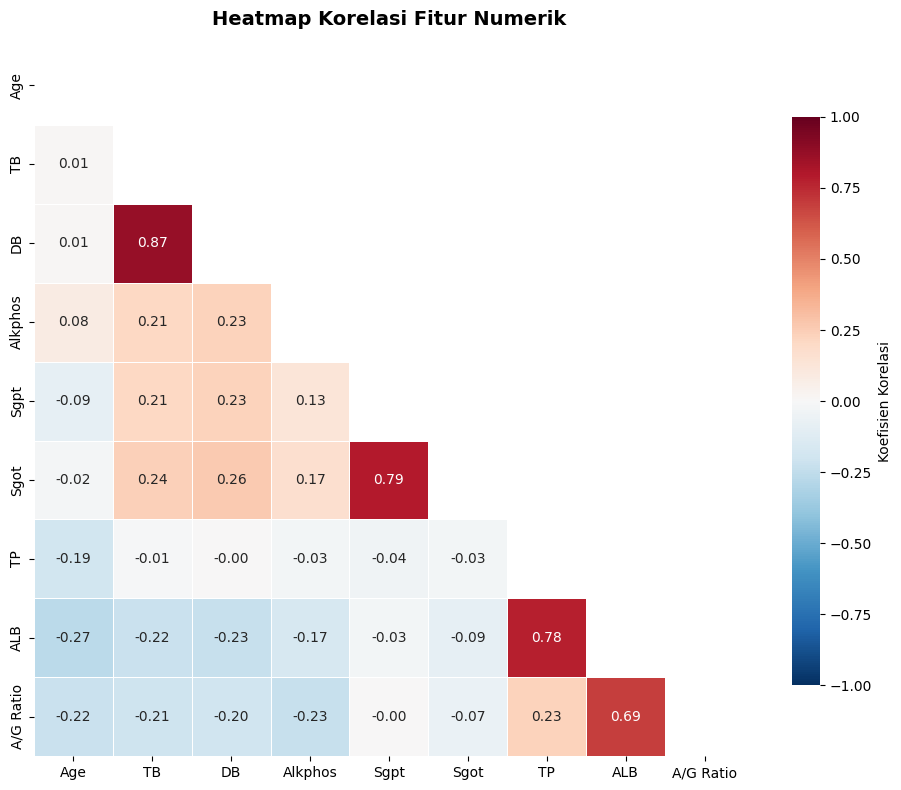

Pasangan fitur dengan korelasi tinggi (|r| > 0.5):
Fitur A      Fitur B             r
-----------------------------------
DB           TB               0.87
Sgot         Sgpt             0.79
ALB          TP               0.78
A/G Ratio    ALB              0.69


In [13]:
corr_matrix = df[num_cols].corr().round(2)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Koefisien Korelasi'}
)
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('Pasangan fitur dengan korelasi tinggi (|r| > 0.5):')
print(f'{"Fitur A":<12} {"Fitur B":<12} {"r":>8}')
print('-' * 35)
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f'{corr_matrix.columns[i]:<12} {corr_matrix.columns[j]:<12} {r:>8.2f}')

Interpretasi:



- **TB–DB (r=0.87):** Korelasi sangat kuat dan positif — kedua fitur ini mengukur hal yang hampir sama (kadar bilirubin). Salah satu bisa dipertimbangkan untuk di-drop pada model linear.

---

- **Sgpt–Sgot (r=0.79):** Korelasi kuat — keduanya merupakan enzim hati yang sering meningkat bersamaan saat terjadi kerusakan hati.

---

- **TP–ALB (r=0.78):** Korelasi kuat — albumin adalah komponen utama dari total protein, sehingga wajar jika keduanya bergerak bersama.

---

- **ALB dan A/G Ratio berkorelasi negatif** dengan fitur bilirubin (TB, DB) — sesuai secara klinis, karena kerusakan hati meningkatkan bilirubin sekaligus menurunkan sintesis albumin.

---

- Untuk model berbasis **tree (Random Forest, XGBoost)**, multikolinearitas tidak menjadi masalah. Namun untuk **Logistic Regression**, pertimbangkan regularisasi atau seleksi fitur.

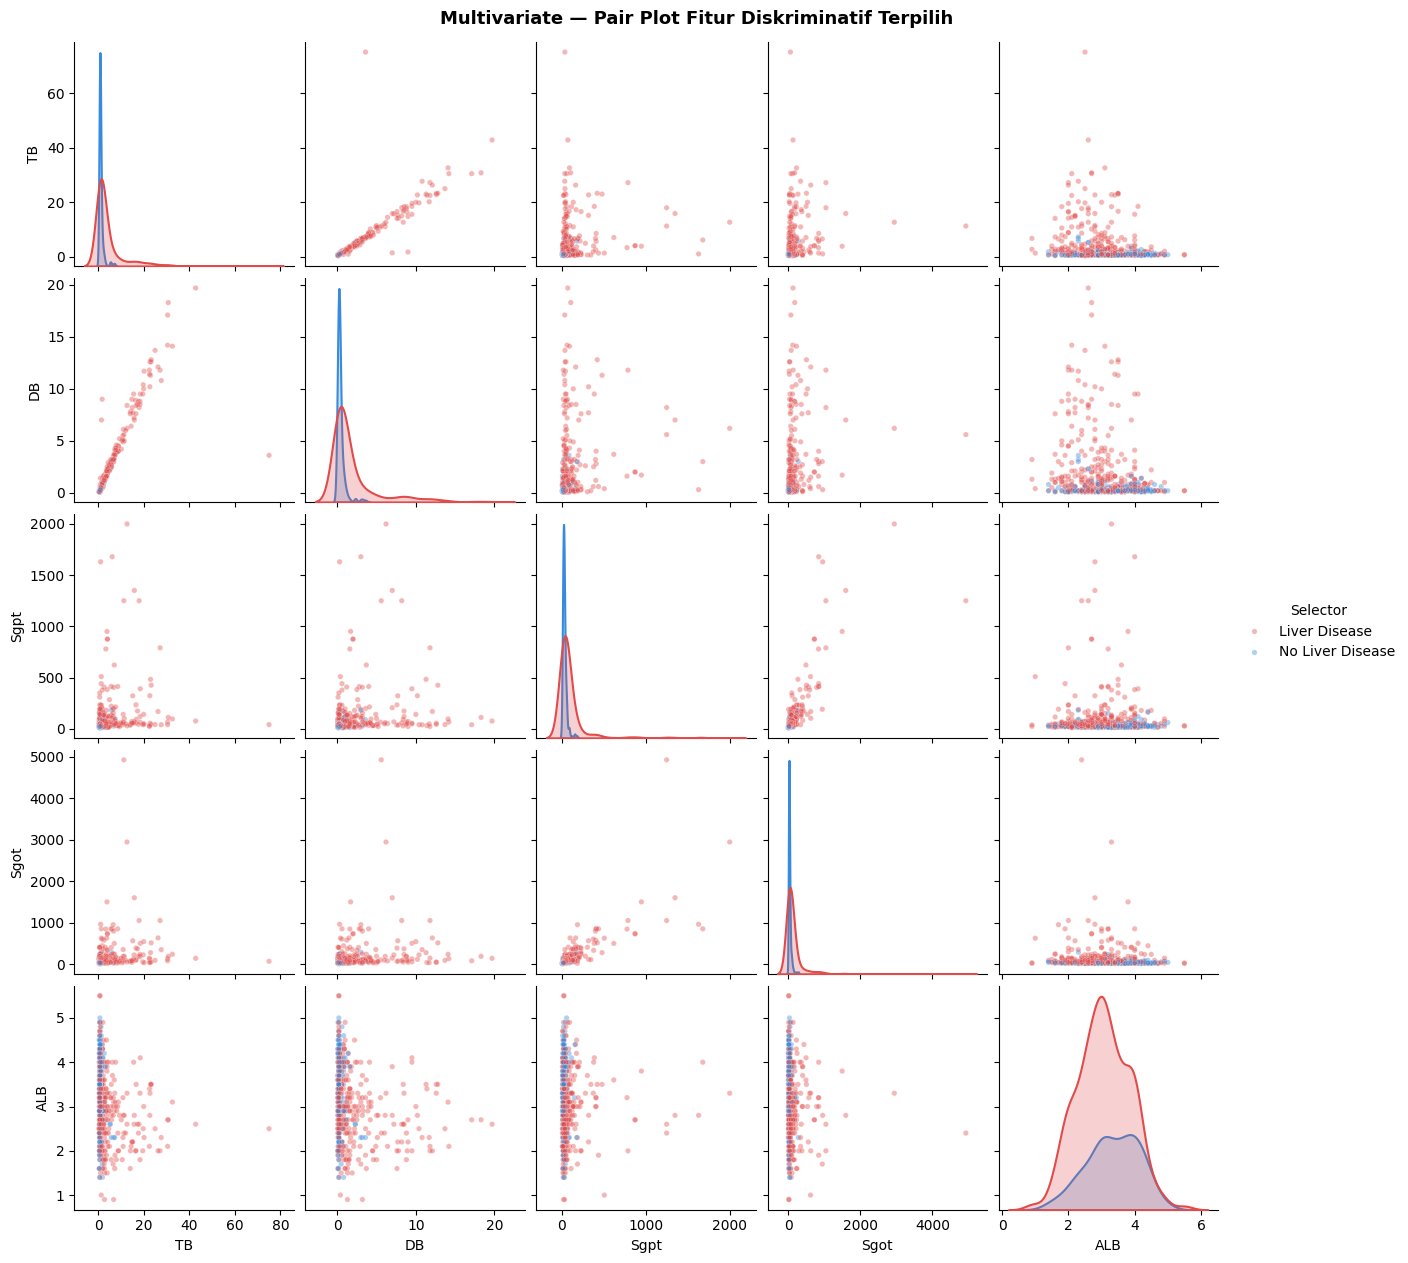

In [14]:
selected = ['TB', 'DB', 'Sgpt', 'Sgot', 'ALB', 'Selector']

pp = sns.pairplot(
    df[selected],
    hue='Selector',
    palette={'Liver Disease': '#E24B4A', 'No Liver Disease': '#378ADD'},
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kws={'linewidth': 1.5}
)
pp.fig.suptitle('Multivariate — Pair Plot Fitur Diskriminatif Terpilih',
                fontsize=13, fontweight='bold', y=1.01)
plt.show()

Interpretasi:



- **Diagonal (KDE):** Fitur **TB, DB, Sgpt, Sgot** menunjukkan pemisahan distribusi yang jelas antara dua kelas — ini mengonfirmasi bahwa keempat fitur ini paling informatif untuk klasifikasi.

---

- **Off-diagonal (Scatter):** Pasangan **TB–DB** dan **Sgpt–Sgot** menunjukkan pola sebaran yang memisahkan kelas dengan cukup baik, meski ada tumpang tindih.


---

- **ALB** memiliki pemisahan distribusi yang lebih lemah, namun tetap berkontribusi saat dikombinasikan dengan fitur lain.

---

- Secara keseluruhan, kombinasi fitur enzim hati memberikan **sinyal yang kuat** untuk membedakan pasien liver disease dari yang sehat.


In [15]:
print('=' * 60)
print('              RINGKASAN HASIL EDA')
print('=' * 60)
print()
print('  [UNIVARIATE]')
print('  • Dataset: 583 baris, 11 kolom, 0 missing values')
print('  • 13 duplikat → perlu di-drop sebelum modeling')
print('  • TB, DB, Sgpt, Sgot, Alkphos: right-skewed & banyak outlier')
print('  • TP, ALB, A/G Ratio: distribusi lebih normal')
print()
print('  [BIVARIATE]')
print('  • Class imbalance: Liver Disease 71.4% vs NLD 28.6%')
print('  • Fitur paling diskriminatif: TB, DB, Sgpt, Sgot, Alkphos')
print('  • ALB & A/G Ratio lebih rendah pada pasien Liver Disease')
print('  • TP: perbedaan antar kelas sangat kecil (<2%)')
print('  • Gender: laki-laki lebih rentan (73.5% vs 64.8%)')
print()
print('  [MULTIVARIATE]')
print('  • Korelasi tinggi: TB-DB (0.87), Sgpt-Sgot (0.79), TP-ALB (0.78)')
print('  • Pair plot: kombinasi fitur enzim hati memisahkan kelas dengan baik')
print()
print('  [REKOMENDASI PREPROCESSING]')
print('  1. Drop 13 baris duplikat')
print('  2. Outlier → tangani dengan median imputation (sudah dilakukan)')
print('  3. Encoding Gender → OneHotEncoding')
print('  4. Scaling fitur numerik → StandardScaler / MinMaxScaler')
print('  5. Class imbalance → class_weight="balanced" atau SMOTE')
print('=' * 60)

              RINGKASAN HASIL EDA

  [UNIVARIATE]
  • Dataset: 583 baris, 11 kolom, 0 missing values
  • 13 duplikat → perlu di-drop sebelum modeling
  • TB, DB, Sgpt, Sgot, Alkphos: right-skewed & banyak outlier
  • TP, ALB, A/G Ratio: distribusi lebih normal

  [BIVARIATE]
  • Class imbalance: Liver Disease 71.4% vs NLD 28.6%
  • Fitur paling diskriminatif: TB, DB, Sgpt, Sgot, Alkphos
  • ALB & A/G Ratio lebih rendah pada pasien Liver Disease
  • TP: perbedaan antar kelas sangat kecil (<2%)
  • Gender: laki-laki lebih rentan (73.5% vs 64.8%)

  [MULTIVARIATE]
  • Korelasi tinggi: TB-DB (0.87), Sgpt-Sgot (0.79), TP-ALB (0.78)
  • Pair plot: kombinasi fitur enzim hati memisahkan kelas dengan baik

  [REKOMENDASI PREPROCESSING]
  1. Drop 13 baris duplikat
  2. Outlier → tangani dengan median imputation (sudah dilakukan)
  3. Encoding Gender → OneHotEncoding
  4. Scaling fitur numerik → StandardScaler / MinMaxScaler
  5. Class imbalance → class_weight="balanced" atau SMOTE





## Data Cleaning

In [16]:
# Display for null values
df.isnull().sum()


Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Selector     0
dtype: int64

In [17]:
# Display for duplicate values
df.duplicated().sum()

np.int64(13)

<Axes: >

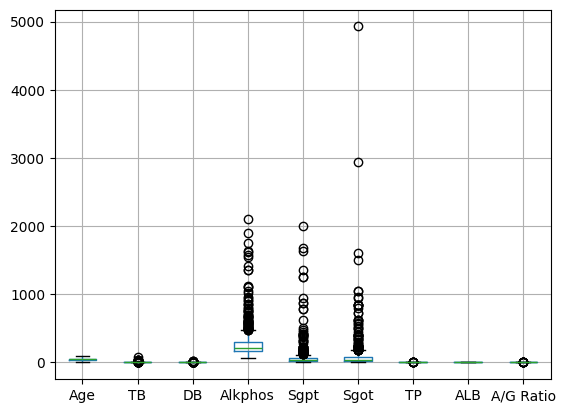

In [18]:
# Display for outliers using boxplot visualization
df.boxplot()

In [19]:
# Display for outliers using IQR method
num_cols = df.select_dtypes('number').columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    if not outliers.empty:
        print(f"Outliers in column '{col}':")
        print(outliers[[col]])
        print("\n")
    else:
        print(f"No outliers found in column '{col}'.\n")

No outliers found in column 'Age'.

Outliers in column 'TB':
       TB
1    10.9
2     7.3
22    6.8
27    6.2
37   14.2
..    ...
572  15.6
574  12.1
575  25.0
576  15.0
577  12.7

[84 rows x 1 columns]


Outliers in column 'DB':
       DB
1     5.5
2     4.1
22    3.0
27    3.0
37    7.8
..    ...
572   9.5
574   6.0
575  13.7
576   8.2
577   8.4

[81 rows x 1 columns]


Outliers in column 'Alkphos':
     Alkphos
1        699
2        490
20       610
21       482
22       542
..       ...
549      768
573      612
574      515
575      560
578      500

[69 rows x 1 columns]


Outliers in column 'Sgpt':
     Sgpt
16    168
18    232
19    232
25    875
26    875
..    ...
560   321
561   233
562   173
569   213
570   131

[73 rows x 1 columns]


Outliers in column 'Sgot':
     Sgot
16    441
18    245
19    245
25    731
26    731
..    ...
548   186
558   330
560   562
561   384
562   367

[66 rows x 1 columns]


Outliers in column 'TP':
      TP
180  2.7
181  3.0
269  2.8
270  9.5

In [20]:
# Handling duplicate values
df.drop_duplicates(inplace=True)

# Display for duplicate values
df.duplicated().sum()

np.int64(0)

In [21]:
# Handling outliers with median imputation
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    median_val = df[col].median()

    df[col] = df[col].apply(lambda x: median_val if x < lower_bound or x > upper_bound else x)

## Feature Engineering

In [22]:
# Display value counts for object features
cat_cols = df.select_dtypes('object').columns

for col in cat_cols:
    print(df[col].value_counts(), '\n')

Gender
Male      430
Female    140
Name: count, dtype: int64 

Selector
Liver Disease       406
No Liver Disease    164
Name: count, dtype: int64 



C:\Users\noirfang\AppData\Local\Temp\ipykernel_17164\3706872893.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes('object').columns


In [23]:
from sklearn.preprocessing import OneHotEncoder

# Label encoding for 'Gender' using One-Hot Encoding technique
# Initialize OneHotEncoder object
encoder = OneHotEncoder(sparse_output=False)

# Fit the 'Gender' feature
encoded_gender = pd.DataFrame(
    encoder.fit_transform(df[['Gender']]),
    columns=encoder.get_feature_names_out()
)

In [24]:
# Display encoded_gender first five rows
encoded_gender.head()

,Gender_Female,Gender_Male
0,1.0,0.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0


In [25]:
# Combine all encoded_gender into final DataFrame
df_temp = df.drop('Gender', axis=1).reset_index(drop=True)
df_cleaned = pd.concat([df_temp[df_temp.columns[:-1]], encoded_gender.reset_index(drop=True), df_temp[['Selector']]], axis=1)

In [26]:
# Display cleaned dataset's first five rows
df_cleaned.head()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Gender_Female,Gender_Male,Selector
0,65,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1.0,0.0,Liver Disease
1,62,1.0,0.3,208.0,64.0,100.0,7.5,3.2,0.74,0.0,1.0,Liver Disease
2,62,1.0,0.3,208.0,60.0,68.0,7.0,3.3,0.89,0.0,1.0,Liver Disease
3,58,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,0.0,1.0,Liver Disease
4,72,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,0.0,1.0,Liver Disease


In [27]:
# Encode target column
df_cleaned['Selector'] = df_cleaned['Selector'].map({'Liver Disease': 1, 'No Liver Disease': 0})
df_cleaned['Selector'].value_counts()

Selector
1    406
0    164
Name: count, dtype: int64

In [28]:
# Memisahkan fitur (X) dan target (y) dari df_cleaned
X = df_cleaned.drop('Selector', axis=1)
y = df_cleaned['Selector']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")

Features shape : (570, 11)
Target shape   : (570,)


In [29]:
# Split train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size : {X_train.shape[0]}")
print(f"Test size  : {X_test.shape[0]}")
print(f"\nTrain target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Train size : 456
Test size  : 114

Train target distribution:
Selector
1    325
0    131
Name: count, dtype: int64

Test target distribution:
Selector
1    81
0    33
Name: count, dtype: int64


In [30]:
# Scaling fitur untuk Logistic Regression fit pada train set untuk menghindari data leakage
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [31]:
# [OPTIONAL] DO NOT RUN this code if you already have the cleaned dataset
# df_cleaned.to_csv('CLEANED_liver_patient_dataset.csv')

# 🤖 Modelling

## Model Selection

In [32]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [33]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [35]:
# scale_pos_weight menggantikan class_weight pada XGBoost
from xgboost import XGBClassifier
scale_pos = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

## Hyperparameter Tuning

In [36]:
# Menggunakan StratifiedKFold agar proporsi kelas tetap terjaga di setiap fold
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [37]:
# Tuning Logistic Regression
lr_param_grid = {
    'C'      : [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver' : ['liblinear', 'saga']
}

lr_search = RandomizedSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_distributions=lr_param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

lr_search.fit(X_train_scaled, y_train)
print("Best params LR :", lr_search.best_params_)
print("Best AUC LR    :", round(lr_search.best_score_, 4))

Best params LR : {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.01}
Best AUC LR    : 0.6965


c:\Users\noirfang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [38]:
# Tuning Random Forest
rf_param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print("Best params RF :", rf_search.best_params_)
print("Best AUC RF    :", round(rf_search.best_score_, 4))

Best params RF : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 15}
Best AUC RF    : 0.7093


In [39]:
# Tuning XGBoost
xgb_param_grid = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'subsample'     : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos, random_state=42, eval_metric='logloss'),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)
print("Best params XGB :", xgb_search.best_params_)
print("Best AUC XGB    :", round(xgb_search.best_score_, 4))

Best params XGB : {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best AUC XGB    : 0.6944


In [40]:
# Mengambil model terbaik dari hasil tuning masing-masing algoritma
best_lr  = lr_search.best_estimator_
best_rf  = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

## Model Evaluation

In [41]:
models = {
    'Logistic Regression': (best_lr, X_train_scaled, X_test_scaled),
    'Random Forest'      : (best_rf, X_train, X_test),
    'XGBoost'            : (best_xgb, X_train, X_test)
}

results = []
for name, (model, X_tr, X_te) in models.items():
    train_auc = roc_auc_score(y_train, model.predict_proba(X_tr)[:, 1])
    test_auc  = roc_auc_score(y_test,  model.predict_proba(X_te)[:, 1])
    results.append({'Model': name, 'Train AUC': round(train_auc, 4), 'Test AUC': round(test_auc, 4)})

pd.DataFrame(results)

,Model,Train AUC,Test AUC
0,Logistic Regression,0.7261,0.7437
1,Random Forest,0.9895,0.7325
2,XGBoost,0.8391,0.7662


Cross-Validation ROC AUC Scores: [0.72364672 0.73372781 0.71893491 0.64023669 0.66508876]
Mean CV ROC AUC: 0.6963
Test Set ROC AUC Score: 0.7662


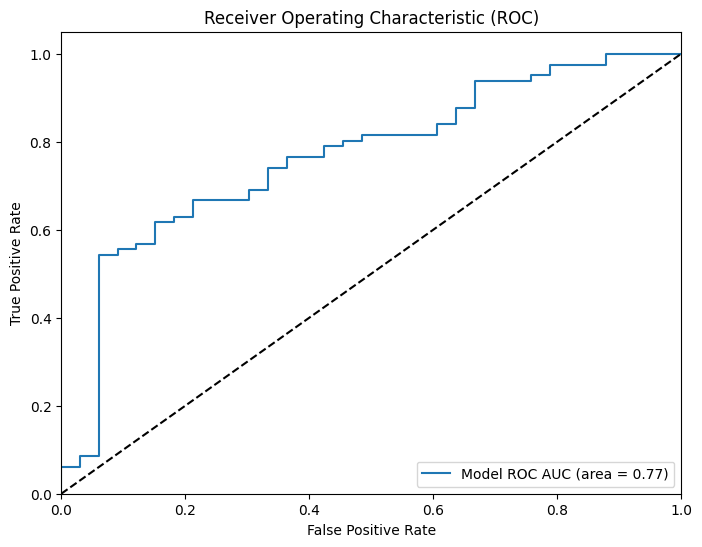


Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.67      0.55        33
           1       0.84      0.69      0.76        81

    accuracy                           0.68       114
   macro avg       0.65      0.68      0.65       114
weighted avg       0.73      0.68      0.70       114



In [42]:
cv_auc_scores = cross_val_score(best_xgb, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"Cross-Validation ROC AUC Scores: {cv_auc_scores}")
print(f"Mean CV ROC AUC: {cv_auc_scores.mean():.4f}")

y_pred_prob = best_xgb.predict_proba(X_test)[:, 1]
roc_auc_test = roc_auc_score(y_test, y_pred_prob)

print(f"Test Set ROC AUC Score: {roc_auc_test:.4f}")
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Model ROC AUC (area = {roc_auc_test:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal garis bantu
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

y_pred = best_xgb.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

## Model Serialization (for deployment)

In [51]:
# Simpan model best_xgb karena good fit dan skor test accuracy paling tinggi
joblib.dump(best_xgb, "../models/liver_pipeline.joblib")
print("Model berhasil disimpan!")
print(type(model))

Model berhasil disimpan!
<class 'xgboost.sklearn.XGBClassifier'>


## App Development

In [52]:
# Load trained pipeline (Model Integration awal)
model = joblib.load("../models/liver_pipeline.joblib")

# Contoh input 
sample_input = pd.DataFrame([{
    "Age": 30,
    "Gender": "Male",
    "TB": 1.0,
    "DB": 0.3,
    "Alkphos": 200,
    "Sgpt": 30,
    "Sgot": 40,
    "TP": 6.5,
    "ALB": 3.2,
    "A/G Ratio": 0.9
}])

# Predict
pred = model.predict(sample_input)
prob = model.predict_proba(sample_input)

print("Prediction:", pred[0])
print("Probability (Liver Disease):", prob[0][1])

Prediction: 0
Probability (Liver Disease): 0.48997962
